# Kinetic analysis of strategy enabling anaerobic production of PHB

In this script, we have performed the ECM analyses for the thermodynamic investigation of the NOG+EMP pathway, also demonstrating how the analysis of other pathways and metabolic engineering strategies could be analyzed by other researchers with the custom-made functions we have developed in this study.

In [27]:
from equilibrator_api import Q_ #for creating quantity variables
import equilibrator_custom_functions as eq #custom functions created during analysis
import numpy as np #numerical package
import math
import matplotlib.pyplot as plt #plotting package

In [28]:
#Setting physiological conditions as a Python dictionary
cellular_conditions = {
            "p_h": str(Q_("7.4")),
            "p_mg": str(Q_(3)),
            "ionic_strength": str(Q_('250 mM')),
            "temperature": str(Q_(20+273.15,"K")),
            "kcat_source": "fwd",
}

#Generating Compound Settings with the default eQuilibrator bounds
cs_default_bounds = eq.obtain_compound_settings("input_metabolite_ranges_default", custom_bounds = True)
import warnings
warnings.filterwarnings('ignore')

In [29]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

lower_qAc = 0.001
upper_qAc = 1
points = 20

# Constants
Volume_per_CDW = Q_(1.9, 'ul/mg').to('L/g')
q_Ac_values = np.linspace(lower_qAc, upper_qAc, points)  # Range of q_Ac values (mmol/gCDW/h)
crit_q_Ac_values = {}  # Store critical q_Ac values for each protein

# Load experimental data from file
df_counts = pd.read_csv('glycolytic_protein_abundance.csv')
df_counts['experimental_concentration'] = df_counts['Abundance']
df_counts['Reaction'] = df_counts['Protein']

# Suppress RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Prepare scatter data
scatter_data = {}

# Loop over q_Ac values
for q_Ac in q_Ac_values:
    # Calculate absolute flux
    q_rate = Q_(q_Ac / 1000, 'mol/g/hour')
    flux_rate = q_rate / Volume_per_CDW
    absolute_flux = flux_rate.to('M/s')

    # Run ECM model
    model = eq.ECM_analysis("NTS_and_EMP_meta_KM_labeling", cs_default_bounds, cellular_conditions, absolute_flux)
    lnC_ECM = model.ecf.optimize_ecm()[1]
    enz_conc = dict(zip(model.reaction_ids, list(np.exp(model.ecf.ECF(lnC_ECM).value))))

    # Prepare predicted abundance DataFrame
    df_predicted = pd.DataFrame(enz_conc.items(), columns=['Protein', 'Concentration'])
    df_predicted['Protein'] = df_predicted['Protein'].replace({
        'TktA': 'TKT', 'TktB': 'TKT',
        'SBPald': 'ALD', 'FBPald': 'ALD'
    })
    df_predicted = df_predicted.groupby('Protein', as_index=False)['Concentration'].sum()

    # Merge experimental and predicted data
    comparison_df = pd.merge(df_counts, df_predicted, left_on='Reaction', right_on='Protein', how='inner')
    comparison_df['Difference'] = abs(comparison_df['experimental_concentration'] - comparison_df['Concentration'])

    # Track critical q_Ac for each protein
    for _, row in comparison_df.iterrows():
        protein = row['Reaction']
        exp_abundance = row['experimental_concentration']
        pred_abundance = row['Concentration']

        if protein not in crit_q_Ac_values:
            crit_q_Ac_values[protein] = {}

        if 'counts' not in crit_q_Ac_values[protein] and pred_abundance >= exp_abundance:
            crit_q_Ac_values[protein]['counts'] = q_Ac

        # Save scatter data
        if protein not in scatter_data:
            scatter_data[protein] = {'q_Ac': [], 'predicted': []}
        scatter_data[protein]['q_Ac'].append(q_Ac)
        scatter_data[protein]['predicted'].append(comparison_df.loc[comparison_df['Reaction'] == protein, 'Concentration'].values[0])

# Extract non-empty values from crit_q_Ac_values
non_empty_q_Ac = {k: v['counts'] for k, v in crit_q_Ac_values.items() if 'counts' in v}

# Set chosen_q_Ac to the minimum value in crit_q_Ac_values
if non_empty_q_Ac:
    chosen_q_Ac = min(non_empty_q_Ac.values())
    highlighted_reaction = [k for k, v in non_empty_q_Ac.items() if v == chosen_q_Ac][0]
else:
    raise ValueError("No valid 'counts' values found in crit_q_Ac_values.")

# Save critical q_Ac values
crit_q_Ac_df = pd.DataFrame.from_dict(crit_q_Ac_values, orient='index')
crit_q_Ac_df.to_csv('critical_q_Ac_values.csv')

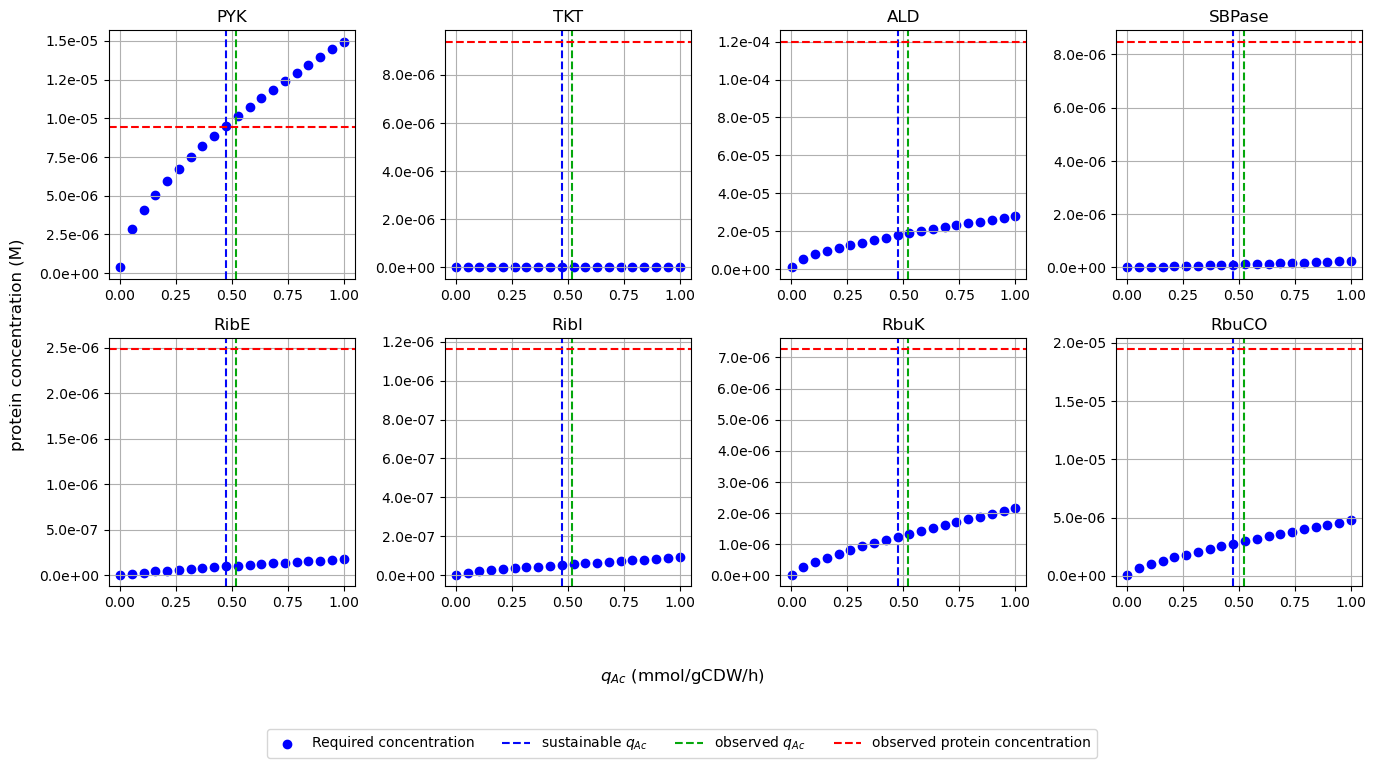

In [30]:
# ==========================
# Figure 1: Selected reactions
# ==========================
selected_reactions = ['PYK', 'TKT', 'ALD', 'SBPase', 'RibE', 'RibI', 'RbuK', 'RbuCO']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(14, 7))
axes = axes.flatten()

# User-defined vertical line q_Ac
experimental_qAc = 0.52
experimental_qAc_color = "#05a70c"  # HTML color for vertical dashed line
theoretical_qAc_color = "#0408f8"  # HTML color for vertical dashed line

for i, protein in enumerate(selected_reactions):
    if protein in scatter_data:
        data = scatter_data[protein]
        ax = axes[i]
        ax.scatter(data['q_Ac'], data['predicted'], label='Required concentration', color='blue')
        ax.axvline(x=chosen_q_Ac, color=theoretical_qAc_color, linestyle='--', label='sustainable $q_{Ac}$')
        ax.axvline(x=experimental_qAc, color=experimental_qAc_color, linestyle='--', label='observed $q_{Ac}$')

        exp_conc_counts = df_counts.loc[df_counts['Reaction'] == protein, 'experimental_concentration']
        if not exp_conc_counts.empty:
            ax.axhline(y=exp_conc_counts.iloc[0], color='red', linestyle='--', label='observed protein concentration')

        ax.set_title(f'{protein}')
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
        ax.grid()

# Single X and Y labels
fig.text(0.5, 0.02, '$q_{Ac}$ (mmol/gCDW/h)', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'protein concentration (M)', va='center', rotation='vertical', fontsize=12)

# Add legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=10)

# Adjust layout to prevent overlap
plt.subplots_adjust(bottom=0.2)  # Increase bottom margin
plt.tight_layout(rect=[0.03, 0.1, 1, 1])  # Adjust bottom margin further

plt.savefig('selected_reactions_plots.tiff', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

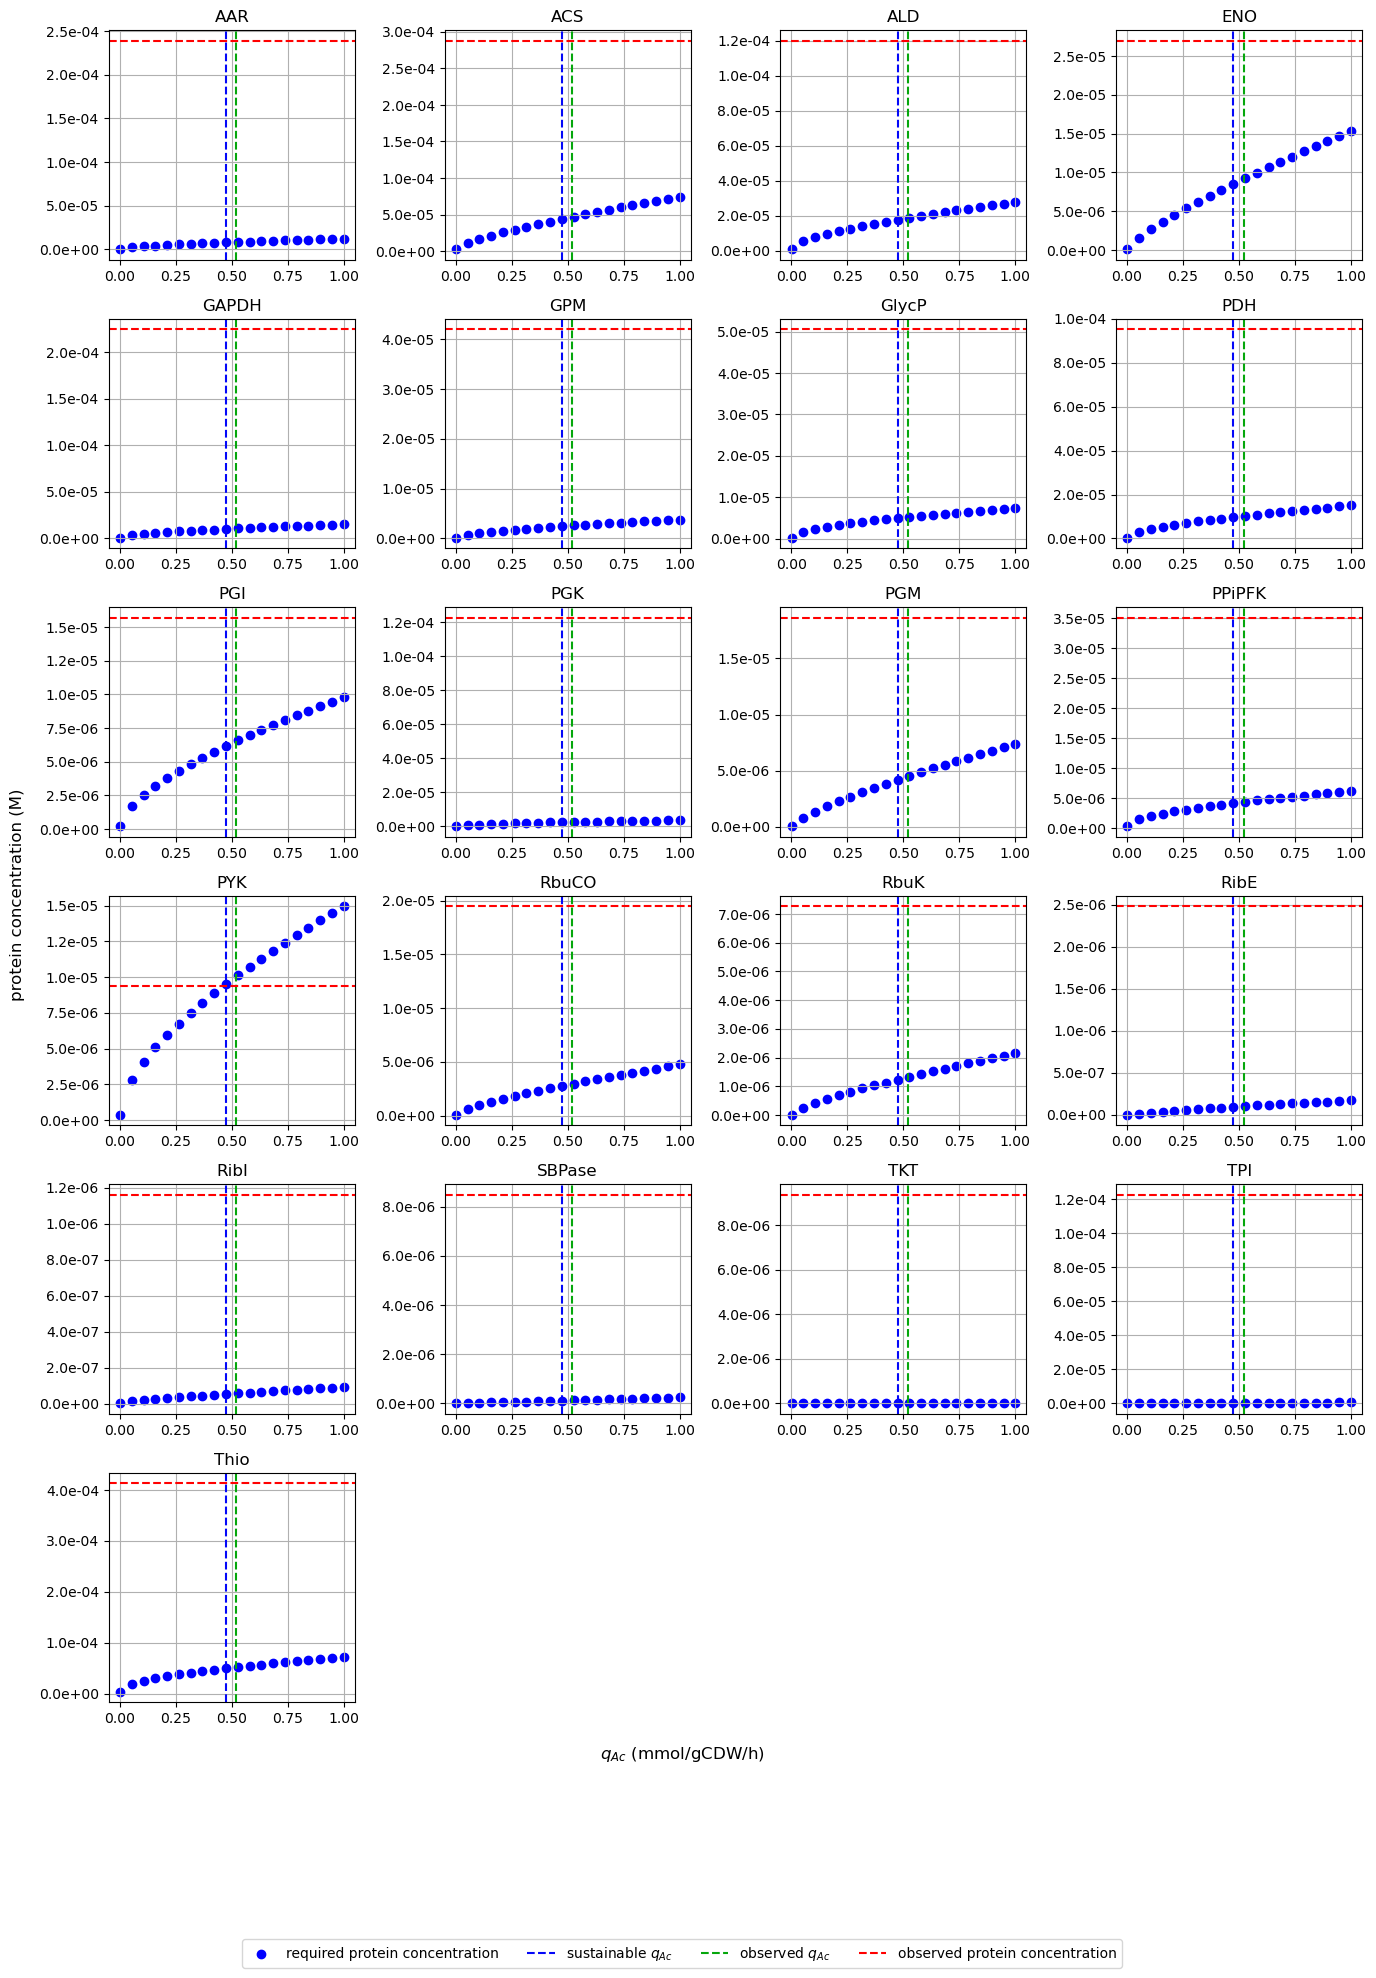

In [31]:
# ==========================
# Figure 2: All proteins
# ==========================
all_proteins = list(scatter_data.keys())
num_proteins = len(all_proteins)
cols = 4
rows = -(-num_proteins // cols)  # Ceiling division

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(14, 3 * rows))
axes = axes.flatten()

for i, protein in enumerate(all_proteins):
    data = scatter_data[protein]
    ax = axes[i]
    ax.scatter(data['q_Ac'], data['predicted'], label='required protein concentration', color='blue')
    ax.axvline(x=chosen_q_Ac, color=theoretical_qAc_color, linestyle='--', label='sustainable $q_{Ac}$')
    ax.axvline(x=experimental_qAc, color=experimental_qAc_color, linestyle='--', label='observed $q_{Ac}$')

    exp_conc_counts = df_counts.loc[df_counts['Reaction'] == protein, 'experimental_concentration']
    if not exp_conc_counts.empty:
        ax.axhline(y=exp_conc_counts.iloc[0], color='red', linestyle='--', label='observed protein concentration')

    ax.set_title(f'{protein}')
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
    ax.grid()

# Hide unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Single X and Y labels
fig.text(0.5, 0.02, '$q_{Ac}$ (mmol/gCDW/h)', ha='center', fontsize=12)
fig.text(0.02, 0.5, 'protein concentration (M)', va='center', rotation='vertical', fontsize=12)

# Add legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=10)

# Adjust layout to prevent overlap
plt.subplots_adjust(bottom=0.03)  # Increase bottom margin
plt.tight_layout(rect=[0.03, 0.03, 1, 1])  # Adjust bottom margin further

plt.savefig('all_proteins_plots.tiff', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [35]:
import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# Constants
Volume_per_CDW = Q_(1.9, 'ul/mg').to('L/g')

# User-defined qAc value (mmol/gCDW/h)
user_qAc =  experimental_qAc 

# Convert qAc to absolute flux
q_rate = Q_(user_qAc / 1000, 'mol/g/hour')
flux_rate = q_rate / Volume_per_CDW
absolute_flux = flux_rate.to('M/s')

# Load experimental data from file
df_counts = pd.read_csv('glycolytic_protein_abundance.csv')
df_counts['experimental_concentration'] = df_counts['Abundance']
df_counts['Reaction'] = df_counts['Protein']

# Suppress RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Run ECM model for the single qAc
model = eq.ECM_analysis("NTS_and_EMP_meta_KM_labeling", cs_default_bounds, cellular_conditions, absolute_flux)
lnC_ECM = model.ecf.optimize_ecm()[1]
enz_conc = dict(zip(model.reaction_ids, list(np.exp(model.ecf.ECF(lnC_ECM).value))))

# Prepare predicted abundance DataFrame
df_predicted = pd.DataFrame(enz_conc.items(), columns=['Protein', 'Concentration'])
df_predicted['Protein'] = df_predicted['Protein'].replace({
    'TktA': 'TKT', 'TktB': 'TKT',
    'SBPald': 'ALD', 'FBPald': 'ALD'
})
df_predicted = df_predicted.groupby('Protein', as_index=False)['Concentration'].sum()

# Merge experimental and predicted data
comparison_df = pd.merge(df_counts, df_predicted, left_on='Reaction', right_on='Protein', how='inner')
comparison_df['Difference'] = abs(comparison_df['experimental_concentration'] - comparison_df['Concentration'])

# Extract experimental and predicted concentrations for plotting
scatter_data = {}
for _, row in comparison_df.iterrows():
    protein = row['Reaction']
    scatter_data[protein] = {
        'experimental': row['experimental_concentration'],
        'predicted': row['Concentration']
    }

# Save results
comparison_df.to_csv('single_qAc_comparison.csv', index=False)


In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
#from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prepare data for plotting
proteins = []
exp_counts = []
predicted_values = []

# Extract data for plotting
for protein, data in scatter_data.items():
    proteins.append(protein)
    exp_counts.append(data['experimental'] * 1e6)  # Convert to µM
    predicted_values.append(data['predicted'] * 1e6)  # Convert to µM

# Sort proteins by experimental abundance in descending order
sorted_indices = np.argsort(exp_counts)[::-1]
proteins = [proteins[i] for i in sorted_indices]
exp_counts = [exp_counts[i] for i in sorted_indices]
predicted_values = [predicted_values[i] for i in sorted_indices]

# Calculate correlation coefficients
r, p_pearson = pearsonr(exp_counts, predicted_values)

# Print correlation metrics
print(f"Pearson correlation coefficient: {r:.2f}, p-value: {p_pearson:.2e}")


Pearson correlation coefficient: 0.83, p-value: 3.46e-06


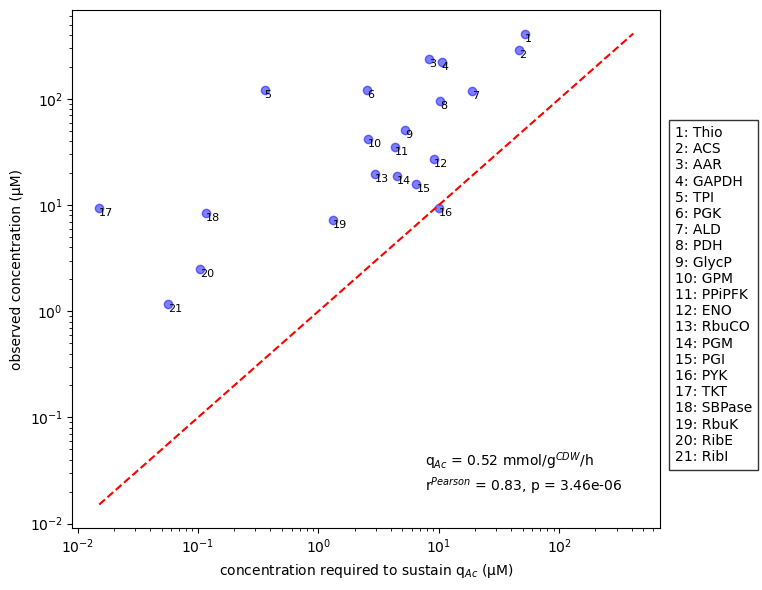

In [37]:
# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))  # Total figure width adjusted to include space for the legend

# Plot data points and labels
labels = []
for i, (x, y, protein) in enumerate(zip(predicted_values, exp_counts, proteins), start=1):
    ax.text(x, y, f'{i}', fontsize=8, color='black', ha='left', va='top')
    ax.scatter(x, y, color='blue', alpha=0.5)
    labels.append(f"{i}: {protein}")

# Add a diagonal line for perfect correlation
max_val = max(max(exp_counts), max(predicted_values))
min_val = min(min(exp_counts), min(predicted_values))
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

# Add text box with Pearson r results
textbox_content = f"q$_{{Ac}}$ = {user_qAc:.2f} mmol/g$^{{CDW}}$/h\nr$^{{Pearson}}$ = {r:.2f}, p = {p_pearson:.2e}"
ax.text(
    0.6, 0.15, textbox_content, transform=ax.transAxes, fontsize=10,
    verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='white')
)

# Add legend for protein identifiers
legend_text = "\n".join(labels)
fig.text(0.85, 0.5, legend_text, fontsize=10, va='center', ha='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Customize plot
ax.set_ylabel('observed concentration (µM)')
ax.set_xlabel('concentration required to sustain q$_{{Ac}}$ (µM)')
ax.set_title('')
ax.set_xscale('log')
ax.set_yscale('log')

# Adjust layout to ensure all elements fit within the saved figure
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Reserve space for legend on the right

# Save the scatter plot
plt.savefig('scatter_plot_correlation_experimental_qAc.tiff', dpi=150, bbox_inches='tight')
plt.show()